<a href="https://colab.research.google.com/github/Ayushi-369/FlyrankAi-Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Ayushi-369/FlyrankAi-Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors the deployed research paper

**Paper:** *Can a model flag declining pages better than an age rule?* — deployed at the URL in `submission/paper_url.txt`.

Sections follow the paper: 1) Question → 2) Data → 3) Methodology → 4) Results vs baseline → 5) Limitations → 6) Ranked recommendations → 7) Artifacts.

> **Revision note.** An earlier version of this notebook used `freshness_tier` as the label. That tier is computed directly from `days_since_last_update`, which was also a feature, so the reported 0.990 precision was label leakage. Section 3 proves it; every number below uses the corrected label.

## 1. Question

**Research question.** On pages the model has never seen (from clients it never trained on), can a small learned model rank "which pages are losing search impressions" better than the hand-written age + CTR rule from Week 4?

**Decision it supports.** A content lead has limited writer hours each week and needs an ordered review queue. Every page a queue flags wrongly costs editorial time; every missed declining page keeps losing visibility.

**Claim level.** Decision-support ranking only. Cross-sectional data cannot show that refreshing a page *causes* recovery.

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, KFold, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score

SEED = 42
LOCAL = "../../data/raw/content_refresh_anonymized.csv"
REMOTE = "https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(LOCAL if os.path.exists(LOCAL) else REMOTE)
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns, {df.client_id.nunique()} pseudonymized clients")

Loaded 30,000 rows x 44 columns, 32 pseudonymized clients


## 2. Data

- **Release:** FlyRank ML Internship dataset, anonymized starter slice `data/raw/content_refresh_anonymized.csv` (one row per content item). The ~79M-row warehouse release was **not** used for this paper.
- **Size:** 30,000 pages across 32 pseudonymized clients. No client names, domains, URLs, titles, or queries exist in the file.
- **Window:** metrics aggregate a trailing 90-day window ending at export; the label compares the last 30 days with the 30 days before.
- **Label:** `declining = 1` when `trend_direction == "down"` (impressions fell more than 20%, last 30d vs previous 30d). Base rate is printed below.
- **Exclusions:** `trend_direction`, `trend_pct`, and the `*_last_30d` / `*_prev_30d` columns are excluded from features (they *are* the label or its inputs). `content_id` and `client_id` are used only for grouping. No rows dropped — the five feature columns have no missing values.

In [2]:
FEATURES = ["content_age_days", "days_since_last_update", "avg_position", "ctr", "engagement_rate"]
y = (df["trend_direction"] == "down").astype(int).values
X = df[FEATURES].values
groups = df["client_id"].values

print("Missing values in features:", int(df[FEATURES].isna().sum().sum()))
print(f"Base rate (share of declining pages): {y.mean():.3f}  -> a random queue is right {y.mean():.1%} of the time")

Missing values in features: 0
Base rate (share of declining pages): 0.542  -> a random queue is right 54.2% of the time


## 3. Methodology

**Assumptions.** Page-level 90-day metrics describe a page's current state well enough to rank it for review; clients differ, so the model must work on clients it has not seen.

**Features (5):** content age, days since last update, average search position, CTR (×100 %), engagement rate (×100 %).

**Baseline (Week-4 rule), unit bug fixed:** score 90 if age > 365 d AND position 1–10 AND CTR < 2 %; 60 if age > 500 d; 50 if position 1–10 AND CTR < 2 %; else 0. (The Week-4 code compared CTR to `0.02`, but CTR is stored as a percentage, so it tested 0.02 % — fixed here to 2.0.)

**Model:** Random Forest, 300 trees, max depth 6, min 20 samples per leaf, balanced class weights, seed 42.

**Validation:** 5-fold `GroupKFold` by `client_id` — every test page belongs to a client the model never trained on. Main metric: precision in the top 10 % of each fold's queue (what an editor actually reviews), with ROC-AUC as a secondary ranking metric. Both model and rule are scored on the identical folds.

**Leakage checks:** (a) prove the old label was leaky; (b) train-without the suspect feature; (c) random vs grouped split gap.

In [3]:
# Leakage check (a): the OLD label. freshness_tier is defined from days_since_last_update.
old_label = df["freshness_tier"].map({"181+": 1, "91-180": 1}).fillna(0).astype(int).values
one_line_rule = (df["days_since_last_update"] >= 91).astype(int).values
print(f"'days_since_last_update >= 91' reproduces the old label on {(one_line_rule == old_label).mean():.1%} of rows")

tr, te = next(GroupShuffleSplit(1, test_size=0.3, random_state=SEED).split(X, old_label, groups))
leaky = RandomForestClassifier(100, max_depth=5, class_weight="balanced", random_state=SEED).fit(X[tr], old_label[tr])
print(f"Old (leaky) setup precision: {precision_score(old_label[te], leaky.predict(X[te])):.3f}  <- not a real result")

'days_since_last_update >= 91' reproduces the old label on 100.0% of rows
Old (leaky) setup precision: 0.990  <- not a real result


In [4]:
def rule_score(d):
    a, p, c = d["content_age_days"].values, d["avg_position"].values, d["ctr"].values
    page1 = (p > 0) & (p <= 10)          # avg_position 0 means 'no data'
    return np.where((a > 365) & page1 & (c < 2.0), 90,
           np.where(a > 500, 60,
           np.where(page1 & (c < 2.0), 50, 0))).astype(float)

def precision_at(y_true, score, frac, seed=0):
    k = max(1, int(round(frac * len(y_true))))
    tiebreak = np.random.default_rng(seed).random(len(score))   # rule has many ties
    return y_true[np.lexsort((tiebreak, -score))[:k]].mean()

def make_model():
    return RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                                  class_weight="balanced", random_state=SEED, n_jobs=-1)

## 4. Results (vs baseline)

Same folds, same metric for both. Base rate shown next to every number.

In [5]:
FRACS = [0.05, 0.10, 0.20, 0.30, 0.50]
rows, importances = [], []
oof = np.zeros(len(df))
for i, (tr, te) in enumerate(GroupKFold(n_splits=5).split(X, y, groups)):
    m = make_model().fit(X[tr], y[tr])
    p = m.predict_proba(X[te])[:, 1]; oof[te] = p
    importances.append(m.feature_importances_)
    rb, yt = rule_score(df.iloc[te]), y[te]
    rows.append({"fold": i + 1, "test_clients": len(set(groups[te])), "test_pages": len(te),
                 "base_rate": yt.mean(), "model_auc": roc_auc_score(yt, p), "rule_auc": roc_auc_score(yt, rb),
                 **{f"model_p@{int(f*100)}%": precision_at(yt, p, f) for f in FRACS},
                 **{f"rule_p@{int(f*100)}%": precision_at(yt, rb, f) for f in FRACS}})
folds = pd.DataFrame(rows)
print(folds.round(3).to_string(index=False))

summary = pd.DataFrame({
    "Base rate": [folds.base_rate.mean(), None],
    "Rule  p@10%": [folds["rule_p@10%"].mean(), folds["rule_p@10%"].std()],
    "Model p@10%": [folds["model_p@10%"].mean(), folds["model_p@10%"].std()],
    "Rule  AUC": [folds.rule_auc.mean(), folds.rule_auc.std()],
    "Model AUC": [folds.model_auc.mean(), folds.model_auc.std()],
}, index=["mean", "sd"]).round(3)
print("\n", summary.to_string())
print(f"\nModel beat the rule at top-10% in {(folds['model_p@10%'] > folds['rule_p@10%']).sum()} of 5 client-held-out folds")

 fold  test_clients  test_pages  base_rate  model_auc  rule_auc  model_p@5%  model_p@10%  model_p@20%  model_p@30%  model_p@50%  rule_p@5%  rule_p@10%  rule_p@20%  rule_p@30%  rule_p@50%
    1             1        7008      0.490      0.616     0.584       0.717        0.688        0.632        0.613        0.577      0.529       0.522       0.559       0.559       0.572
    2             7        5731      0.645      0.520     0.499       0.756        0.714        0.668        0.653        0.663      0.693       0.654       0.647       0.642       0.640
    3             8        5753      0.379      0.708     0.536       0.493        0.548        0.542        0.540        0.526      0.462       0.456       0.399       0.399       0.411
    4             8        5755      0.622      0.636     0.448       0.844        0.814        0.764        0.716        0.677      0.573       0.538       0.548       0.558       0.580
    5             8        5753      0.585      0.591     0.511  

In [6]:
# Leakage check (b): train WITHOUT days_since_last_update. (c): random split vs grouped split.
F4 = [f for f in FEATURES if f != "days_since_last_update"]
X4 = df[F4].values
no_dslu, rand = [], []
for tr, te in GroupKFold(5).split(X4, y, groups):
    p = make_model().fit(X4[tr], y[tr]).predict_proba(X4[te])[:, 1]
    no_dslu.append((roc_auc_score(y[te], p), precision_at(y[te], p, 0.10)))
for tr, te in KFold(5, shuffle=True, random_state=SEED).split(X):
    p = make_model().fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
    rand.append((roc_auc_score(y[te], p), precision_at(y[te], p, 0.10)))
print(f"Without days_since_last_update: AUC {np.mean(no_dslu,0)[0]:.3f}, p@10% {np.mean(no_dslu,0)[1]:.3f}  (no collapse -> not a leak)")
print(f"Random (non-grouped) split:     AUC {np.mean(rand,0)[0]:.3f}, p@10% {np.mean(rand,0)[1]:.3f}  (inflated by client memorization)")
print(f"Grouped split (reported):       AUC {folds.model_auc.mean():.3f}, p@10% {folds['model_p@10%'].mean():.3f}")

imp = pd.Series(np.mean(importances, 0), FEATURES).sort_values(ascending=False)
print("\nMean feature importance across folds:\n", imp.round(3).to_string())

Without days_since_last_update: AUC 0.606, p@10% 0.697  (no collapse -> not a leak)
Random (non-grouped) split:     AUC 0.706, p@10% 0.782  (inflated by client memorization)
Grouped split (reported):       AUC 0.614, p@10% 0.668

Mean feature importance across folds:
 avg_position              0.425
content_age_days          0.331
days_since_last_update    0.120
ctr                       0.100
engagement_rate           0.024


In [7]:
# Observed associations (whole slice, descriptive only)
df["declining"] = y
df["age_quartile"] = pd.qcut(df["content_age_days"], 4)
print(df.groupby("age_quartile", observed=True)["declining"].agg(["mean", "size"]).round(3))
df["updated_recently"] = np.where(df["days_since_last_update"] >= 91, "not updated 91+ d", "updated < 91 d")
print(df.groupby("updated_recently")["declining"].agg(["mean", "size"]).round(3))
print(df.groupby("position_tier")["declining"].agg(["mean", "size"]).round(3))

                  mean  size
age_quartile                
(89.999, 132.0]  0.600  7518
(132.0, 236.0]   0.640  8128
(236.0, 333.0]   0.494  6917
(333.0, 564.0]   0.422  7437
                    mean   size
updated_recently               
not updated 91+ d  0.608   9345
updated < 91 d     0.512  20655
                mean   size
position_tier              
deep           0.344   1319
page_1         0.570  11814
page_3_5       0.562   7242
striking       0.610   7304
top_3          0.241   2321


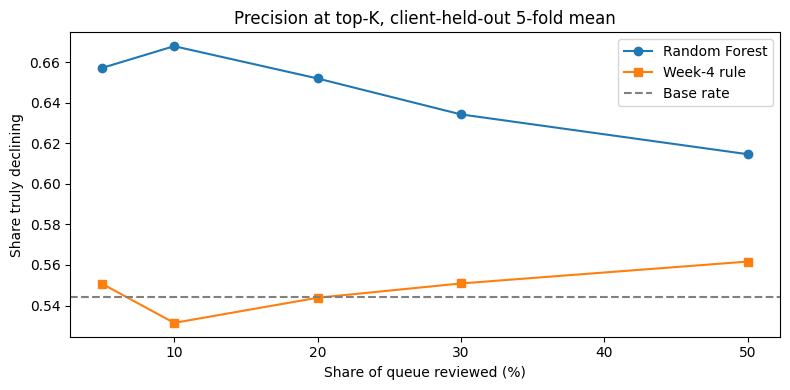

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
pct = [int(f*100) for f in FRACS]
ax.plot(pct, [folds[f"model_p@{p}%"].mean() for p in pct], marker="o", label="Random Forest")
ax.plot(pct, [folds[f"rule_p@{p}%"].mean() for p in pct], marker="s", label="Week-4 rule")
ax.axhline(folds.base_rate.mean(), ls="--", c="gray", label="Base rate")
ax.set_xlabel("Share of queue reviewed (%)"); ax.set_ylabel("Share truly declining")
ax.set_title("Precision at top-K, client-held-out 5-fold mean"); ax.legend(); plt.tight_layout(); plt.show()

## 5. Limitations

- **Modest, variable skill.** Top-10 % precision averages 0.67 against a 0.54 base rate, and ranges 0.55–0.81 across folds. In fold 5 the model's top 10% was no better than that fold's base rate. One fold is a single large client, so results depend on which clients are held out.
- **Window overlap.** CTR, position and engagement are 90-day aggregates that include the 30-day label window. They are not the label, but they are not strictly "before" it either; a forward-window design on the warehouse release would be stronger.
- **Short-term label.** A >20 % drop between two 30-day windows includes seasonality and noise, not only true decay.
- **Descriptive, not causal.** Nothing here shows a refresh restores traffic.
- **Starter slice only.** 30k rows from 32 clients; not validated on the full release.

## 6. Ranked recommendations

1. Replace the age-first rule with the model score for ordering the weekly review queue; review the top 10 % first (observed ~67 % declining vs 54 % at random).
2. Stop treating age alone as a decay signal: in this slice the oldest quartile declined *least* (42 %).
3. Within the queue, look first at pages not updated in 91+ days (61 % declined vs 51 %) and pages ranking 11–20 (61 % declined, the highest of any position tier).
4. Keep an editor in the loop; log accept/reject per flagged page to measure real precision.
5. Before scaling, rerun on the warehouse release with a forward label window.

In [9]:
# Ranked queue from OUT-OF-FOLD scores (no page is scored by a model that saw it)
queue = df.assign(decline_score=oof).sort_values("decline_score", ascending=False)
top = queue.head(int(0.10 * len(queue)))
print(f"Top-10% queue: {len(top):,} pages, observed declining share {top.declining.mean():.3f} (base {y.mean():.3f})")
os.makedirs("../outputs", exist_ok=True)
top[["content_id", "decline_score", "avg_position", "days_since_last_update", "content_age_days"]].to_csv(
    "../outputs/capstone_ranked_queue_top10pct.csv", index=False)
print("Saved ../outputs/capstone_ranked_queue_top10pct.csv (pseudonymous ids only)")

Top-10% queue: 3,000 pages, observed declining share 0.659 (base 0.542)
Saved ../outputs/capstone_ranked_queue_top10pct.csv (pseudonymous ids only)


## 7. Artifacts the paper embeds

The paper (`docs/index.html`) embeds: the fold table and summary from Section 4, the precision-at-K chart, the per-fold comparison, the random-vs-grouped split gap, the age-quartile association, and the leakage checks from Section 3. All numbers in the paper come from the cells above (seed 42).

**Reproducibility & acknowledgments.** Rerun: open this notebook in Colab (badge at top) and *Run all*. Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

## ML-12 closing cells

**5-minute demo outline.** (1) The question and the editor's decision — 30 s. (2) Data and label — 45 s. (3) The leakage I found in my own first draft: 0.99 → proof it was the label — 1 min. (4) Honest results: model vs rule on client-held-out folds — 1.5 min. (5) Limitations — 45 s. (6) Recommendations and next step — 30 s.

**Social post.** My first model scored 0.99 precision. It was wrong: the label was built from one of my features. After fixing it and testing on clients the model never saw, it flags declining pages at 67 % vs 54 % by chance, beating the rule-of-thumb in 5/5 folds. Paper + notebook linked.

**Employer 3-sentencer.** I built a page-decline ranking model on 30,000 pages of anonymized production search data from the FlyRank ML Internship. I caught and documented label leakage in my own first version, then validated on held-out clients. The corrected model lifts top-10 % precision from 0.54 (random) and 0.53 (rule) to 0.67.

## Self-check

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card.
- [x] Deployed paper has all 9 sections, including the Abstract and Acknowledgments & data credit (https://flyrank.ai)
- [x] ML-12 closing cells present